In [1]:
import xarray as xr

ds_truth = xr.open_zarr("data/era5_indonesia_2018-2022.zarr")
ds_forecast = xr.open_zarr("data/ifs_lowres_indonesia_2018-2022.zarr")

print(ds_truth)
print(ds_forecast)

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    2m_temperature            (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 41, lati

C:\Users\zharif\AppData\Local\Temp\ipykernel_20360\520338640.py:4: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_forecast = xr.open_zarr("data/ifs_lowres_indonesia_2018-2022.zarr")


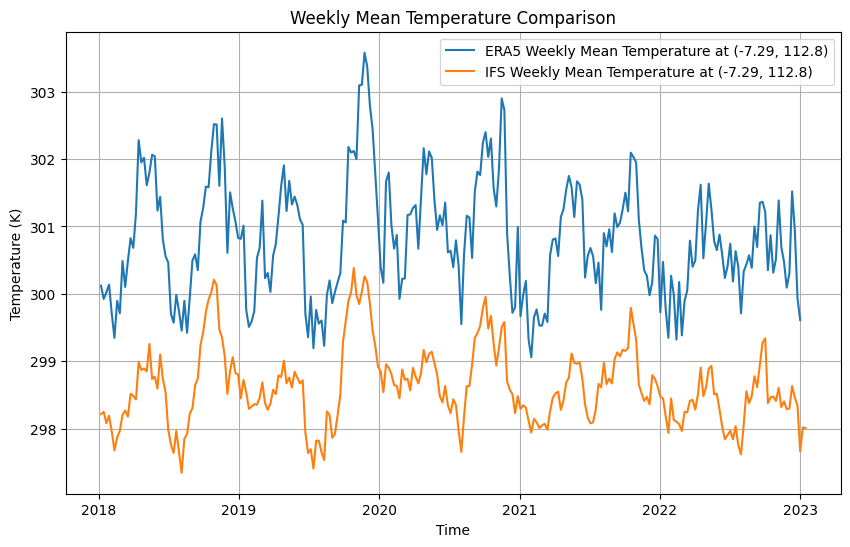

In [ ]:
import numpy as np

# --- Build valid_time for IFS and swap dimension ---
valid_time = ds_forecast["time"] + ds_forecast["prediction_timedelta"]
ds_forecast = ds_forecast.assign_coords(valid_time=("time", valid_time)).swap_dims({"time":"valid_time"})

# If prediction_timedelta is still a dim, pick a lead or stack leads into channels:
lead = np.timedelta64(24, "h")
ds_forecast_lead = ds_forecast.sel(prediction_timedelta=lead)

# --- Match time stamps (nearest or exact) ---
# ERA5 hourly; IFS 3/6-h steps; use nearest with tolerance
ds_truth_aligned = ds_truth.reindex(time=ds_forecast_lead.valid_time, method="nearest", tolerance="1H")
ds_truth_aligned = ds_truth_aligned.rename({"time":"valid_time"}).assign_coords(valid_time=ds_forecast_lead.valid_time)